# Multiple Linear Regression using scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("Loan_default.csv")

# Features
X = df[["Income", "CreditScore", "Age"]]

# Target
y = df["LoanAmount"]

# Train Model
model = LinearRegression()
model.fit(X, y)

# Print Parameters
print("Coefficients:")
print("Income Weight      :", model.coef_[0])
print("CreditScore Weight :", model.coef_[1])
print("Age Weight         :", model.coef_[2])

print("\nIntercept :", model.intercept_)

Coefficients:
Income Weight      : -0.0015750262244766874
CreditScore Weight : 0.561191515052959
Age Weight         : -10.458766975990768

Intercept : 127841.47045086985


## Predict Loan Amount

In [3]:
sample = [[65000, 720, 35]]

prediction = model.predict(sample)

print("Predicted Loan Amount =", prediction[0])

Predicted Loan Amount = 127777.09479295732


/home/nafisa/D Drive/Nafisa college materials/ML/venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Gradient Descent from Scratch

In [6]:
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Loan_default_cleaned.csv")

# Features
X = df[["income", "creditscore", "age"]].values.astype(float)

# Target
Y = df["loanamount"].values.astype(float)

# Number of samples
n = len(Y)

# Number of features
m = X.shape[1]

# Initialize Weights and Bias
weights = np.zeros(m)

bias = 0

learning_rate = 0.000001

epochs = 5000

loss_history = []

for epoch in range(epochs):

    # Prediction
    Y_pred = np.dot(X, weights) + bias

    # Error
    error = Y_pred - Y

    # Loss
    loss = np.mean(error ** 2)

    loss_history.append(loss)

    # Gradient of Weights
    dw = (2 / n) * np.dot(X.T, error)

    # Gradient of Bias
    db = (2 / n) * np.sum(error)

    # Update Parameters
    weights = weights - learning_rate * dw

    bias = bias - learning_rate * db

    if epoch % 500 == 0:
        print("Epoch:", epoch)
        print("Loss:", loss)

print("\nFinal Weights")

print("Income Weight      :", weights[0])

print("CreditScore Weight :", weights[1])

print("Age Weight         :", weights[2])

print("Bias :", bias)

Epoch: 0
Loss: 1.0000000000000002
Epoch: 500
Loss: 0.9999999855428238
Epoch: 1000
Loss: 0.9999999711145383
Epoch: 1500
Loss: 0.9999999567150862
Epoch: 2000
Loss: 0.99999994234441
Epoch: 2500
Loss: 0.9999999280024523
Epoch: 3000
Loss: 0.9999999136891551
Epoch: 3500
Loss: 0.9999998994044617
Epoch: 4000
Loss: 0.9999998851483148
Epoch: 4500
Loss: 0.9999998709206571

Final Weights
Income Weight      : -8.61018981510157e-06
CreditScore Weight : 1.2549732703694346e-05
Age Weight         : -2.2017184779916682e-05
Bias : 4.0780320116545055e-19


## Plot Loss Curve

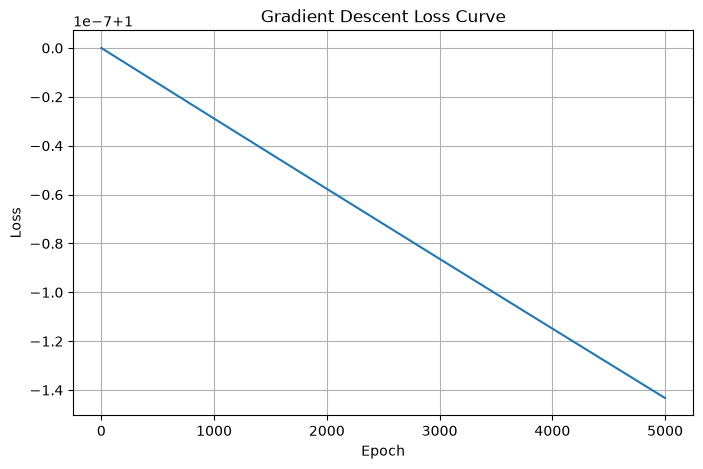

In [8]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Gradient Descent Loss Curve")

plt.grid(True)

plt.show()

## Prediction Using Gradient Descent

In [9]:
sample = np.array([65000, 720, 35])

prediction = np.dot(sample, weights) + bias

print("Predicted Loan Amount =", prediction)

Predicted Loan Amount = -0.5513971319022393


## Compare with scikit-learn

In [10]:
print("\n------ Comparison ------")

print("Scikit-Learn Coefficients")
print(model.coef_)

print("Gradient Descent Weights")
print(weights)

print("\nScikit-Learn Intercept")
print(model.intercept_)

print("Gradient Descent Bias")
print(bias)


------ Comparison ------
Scikit-Learn Coefficients
[-0.00086628  0.00125882 -0.00221313]
Gradient Descent Weights
[-8.61018982e-06  1.25497327e-05 -2.20171848e-05]

Scikit-Learn Intercept
3.9861743693965554e-17
Gradient Descent Bias
4.0780320116545055e-19
